# Paper figures
Figures for the paper.

## Latency
### Run experiments
Base command:
```bash
bash run.sh --port 18080 --steps 10 --width 512 --height 320
```
Get results:
```bash
curl -s http://localhost:18080/health | jq '.wan.gen_timer | to_entries | last.value'

format_gen_timer_csv() {
  jq -r '
    def r3: (. * 1000 | round) / 1000;
    def sum_prefix($p):
      to_entries
      | map(select(.key | startswith($p)) | .value)
      | add // 0;
    def sum_dit:
      to_entries
      | map(select(.key | test("^dit_[0-9]+$")) | .value)
      | add // 0;
    [
      ((.text_encoder // 0) | r3),
      ((.image_encoder // 0) | r3),
      ((.vae_encoder // 0) | r3),
      ((.scheduler_setup // 0) | r3),
      (sum_dit | r3),
      (sum_prefix("dit_cond_") | r3),
      (sum_prefix("dit_uncond_") | r3),
      (
        to_entries
        | map(select(.key | test("^scheduler_[0-9]+$")) | .value)
        | add // 0
      ),
      ((.vae_decoder // 0) | r3),
      ((.output // 0) | r3),
      ((.total // 0) | r3)
    ] | @csv
  '
}
curl -s http://localhost:$PORT/health | jq '.wan.gen_timer | to_entries | last.value'  > tmp-out.json 
cat tmp-out.json  | format_gen_timer_csv
```

Base
```bash
PORT=18080
WORLD_SIZE=`curl -s http://localhost:$PORT/health | jq '.wan.world_size'`
STEPS=10
WIDTH=640
HEIGHT=400
FRAMES=81

for i in {1..3}; do
bash run.sh --port $PORT --steps $STEPS --frames $FRAMES --width $WIDTH --height $HEIGHT > /dev/null
curl -s http://localhost:$PORT/health | jq '.wan.gen_timer | to_entries | last.value'  > tmp-out.json
OUT_CSV=`cat tmp-out.json  | format_gen_timer_csv`
echo "$i,$WORLD_SIZE,$STEPS,3,$FRAMES,$WIDTH,$HEIGHT,$OUT_CSV" >> wan-timing-a100.csv
done
```

Sensitivity to number of steps:
```bash
WIDTH=640
HEIGHT=400
FRAMES=81
for i in {1..3}; do
for STEPS in 1 2 5 8 10 15 20 25 30; do
bash run.sh --port $PORT --steps $STEPS --frames $FRAMES --width $WIDTH --height $HEIGHT > /dev/null
curl -s http://localhost:$PORT/health | jq '.wan.gen_timer | to_entries | last.value'  > tmp-out.json
OUT_CSV=`cat tmp-out.json  | format_gen_timer_csv`
echo "$i,$WORLD_SIZE,$STEPS,3,$FRAMES,$WIDTH,$HEIGHT,$OUT_CSV" >> wan-timing-a100.csv
done
done
```

Sensitivity to resolution:
```bash
STEPS=10
FRAMES=81
for i in {1..3}; do
for res in 256x160 320x200 512x320 640x400 768x480 1024x640 1280x800; do
WIDTH=${res%x*}
HEIGHT=${res#*x}
bash run.sh --port $PORT --steps $STEPS --frames $FRAMES --width $WIDTH --height $HEIGHT > /dev/null
curl -s http://localhost:$PORT/health | jq '.wan.gen_timer | to_entries | last.value'  > tmp-out.json
OUT_CSV=`cat tmp-out.json | format_gen_timer_csv`
echo "$i,$WORLD_SIZE,$STEPS,3,$FRAMES,$WIDTH,$HEIGHT,$OUT_CSV" >> wan-timing-a100.csv
done
done
```

Sensitivity to number of frames:
```bash
STEPS=10
WIDTH=640
HEIGHT=400
for i in {1..3}; do
for FRAMES in 1 5 21 41 61 81; do
bash run.sh --port $PORT --steps $STEPS --frames $FRAMES --width $WIDTH --height $HEIGHT > /dev/null
curl -s http://localhost:$PORT/health | jq '.wan.gen_timer | to_entries | last.value'  > tmp-out.json
OUT_CSV=`cat tmp-out.json  | format_gen_timer_csv`
echo "$i,$WORLD_SIZE,$STEPS,3,$FRAMES,$WIDTH,$HEIGHT,$OUT_CSV" >> wan-timing-a100.csv
done
done
```

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from typing import Optional

In [2]:
import sys
sys.path.append("../simulator")

from plot_utils import _get_time_ticklabels
from plot_utils import get_color_map

from utils import get_pareto_frontier_paper

from constants import SECONDS_IN_HOUR

In [ ]:
DPI = 300
PAPER_FIG_SIZE = (5.5, 2)
#PAPER_FIG_SIZE_TALL = (5.5, 3)
PAPER_FIG_SIZE_TALL = (5.5, 2.5)

DATA_FOLDER = Path("~/realtimevideogen/paper/data")
OUT_FOLDER = Path("~/realtimevideogen/paper/figures")

FILE_FORMATS = ['svg', 'pdf']

In [4]:
FPS = 16
WORLD_SIZE = 8
FRAME_NUM = 81
SAMPLING_STEPS = 10

In [5]:
df_results = pd.read_csv(DATA_FOLDER / "wan-timing-a100.csv")
df_results["sched"] = df_results["sched_setup"] + df_results["sched"]
df_results["other_time"] = df_results["total_time"] - (
    df_results["txt_enc"] + df_results["img_enc"] + df_results["vae_enc"] +
    df_results["dit"] + df_results["sched"] +
    df_results["vae_dec"] + df_results["output"]
)
df_results["pixels"] = df_results["width"] * df_results["height"]
df_results

,#run_id,world_size,sampling_steps,colors,frames,width,height,txt_enc,img_enc,vae_enc,sched_setup,dit,dit_cond,dit_uncond,sched,vae_dec,output,total_time,other_time,pixels
0,0,1,10,3,81,640,400,0.12,0.04,2.09,0,87.27,43.62,43.63,0.01,3.42,0.57,93.59,0.07,256000
1,0,1,10,3,81,640,400,0.12,0.04,2.09,0,87.46,43.71,43.71,0.02,3.42,0.56,93.75,0.04,256000
2,1,1,1,3,81,640,400,0.12,0.04,2.09,0,8.74,4.37,4.37,0.00,3.41,0.64,15.08,0.04,256000
3,1,1,2,3,81,640,400,0.12,0.03,2.08,0,17.46,8.72,8.74,0.00,3.41,0.61,23.76,0.05,256000
4,1,1,5,3,81,640,400,0.12,0.04,2.08,0,43.71,21.84,21.86,0.02,3.42,0.60,50.03,0.04,256000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,2,2,10,3,81,640,400,0.16,0.03,2.15,0,53.28,26.61,26.63,0.28,3.45,0.51,59.89,0.03,256000
168,3,2,10,3,81,640,400,0.16,0.03,2.16,0,53.34,26.69,26.70,0.37,3.45,0.51,60.07,0.05,256000
169,1,2,10,3,81,640,400,0.16,0.03,2.14,0,53.03,26.51,26.52,0.00,3.45,0.51,59.34,0.02,256000
170,2,2,10,3,81,640,400,0.16,0.03,2.15,0,53.33,26.67,26.68,1.75,3.46,0.51,61.42,0.03,256000


## Breakdown

In [6]:
FPS = 16
WORLD_SIZE = 1
FRAME_NUM = 81
WIDTH = 640
HEIGHT = 400
SAMPLING_STEPS = 10
PIXELS = WIDTH * HEIGHT
MODEL_NAME = "Wan2.1-I2V-14B-480P"

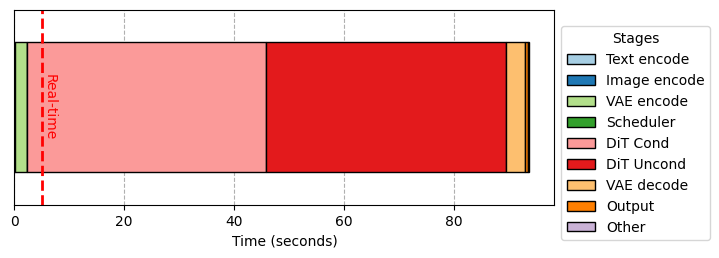

In [7]:
data = df_results[
    (df_results["world_size"] == WORLD_SIZE) &
    (df_results["frames"] == FRAME_NUM) &
    (df_results["sampling_steps"] == SAMPLING_STEPS) &
    (df_results["width"] == WIDTH) &
    (df_results["height"] == HEIGHT)
][["txt_enc", "img_enc", "vae_enc", "sched", "dit_cond", "dit_uncond", "vae_dec", "output", "other_time"]].mean().rename({
    "txt_enc": "Text encode",
    "img_enc": "Image encode",
    "vae_enc": "VAE encode",
    "sched": "Scheduler",
    #"dit": "Denoising Steps",
    "dit_cond": "DiT Cond",
    "dit_uncond": "DiT Uncond",
    "vae_dec": "VAE decode",
    "output": "Output",
    "other_time": "Other",
})

#fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)
fig, ax = plt.subplots(figsize=(7, 2.4))
left = 0
colors = plt.cm.Paired(range(len(data)))  # type: ignore
for (label, value), color in zip(data.items(), colors):
    ax.barh(
        " ",
        value,
        left=left,
        label=label,
        color=color,
        edgecolor="black",
        height=1,
    )
    left += value

ax.axvline(x=FRAME_NUM/FPS, color="red", linestyle='--', label="", lw=2)
ax.text(FRAME_NUM/FPS + 0.1, 0, "Real-time", color="red", va="center", fontsize=10, rotation=270)

# Make the bar slim
ax.set_ylim(-0.75, 0.75)
ax.set_yticks([]) 

ax.xaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)
plt.xlabel("Time (seconds)")
#plt.title(f"Time to generate a video of {FRAME_NUM/FPS:.1f} seconds with {MODEL_NAME} using {SAMPLING_STEPS} steps and {WORLD_SIZE} A100 GPUs")
plt.legend(
    title="Stages",
    bbox_to_anchor=(1, 0.95),
    loc='upper left'
)
plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/char_breakdown.{file_format}", dpi=DPI, bbox_inches='tight', pad_inches=0)
plt.show()

## Steps
Impact of the number of de-noising steps.

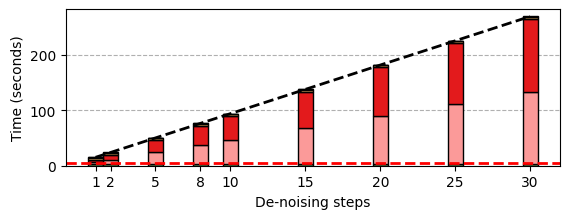

In [8]:
GROUP_BY = "sampling_steps"
data = df_results[
    (df_results["world_size"] == WORLD_SIZE) &
    (df_results["frames"] == FRAME_NUM) &
    (df_results["width"] == WIDTH) &
    (df_results["height"] == HEIGHT)
][[
    GROUP_BY, "txt_enc", "img_enc", "vae_enc", "sched",
    "dit_cond", "dit_uncond", "vae_dec", "output", "other_time"
]].groupby(GROUP_BY).mean().rename(columns={
    "txt_enc": "Text encode",
    "img_enc": "Image encode",
    "vae_enc": "VAE encode",
    "sched": "Scheduler",
    "dit_cond": "DiT Cond",
    "dit_uncond": "DiT Uncond",
    "vae_dec": "VAE decode",
    "output": "Output",
    "other_time": "Other",
})

fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)
colors = plt.cm.Paired(range(len(data.columns)))
bottom = np.zeros(len(data))
for i, (col, color) in enumerate(zip(data.columns, colors)):
    ax.bar(
        data.index,
        data[col],
        bottom=bottom,
        label=col,
        color=color,
        edgecolor="black",
        width=0.99
    )
    bottom += data[col].values

ax.plot(
    data.index,
    data.sum(axis=1),
    color="black",
    linestyle='--',
    label="Total Time",
    lw=2)

ax.axhline(y=FRAME_NUM/FPS, color="red", linestyle='--', label="Target Time", lw=2)
ax.set_xticks(data.index)
ax.set_xticklabels(data.index, rotation=0)
ax.set_xlabel("De-noising steps")
ax.set_ylabel("Time (seconds)")
ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/char_steps.{file_format}", dpi=DPI, bbox_inches='tight', pad_inches=0)
plt.show()

## Resolution
Impact to the resolution in 16:10.

/tmp/ipykernel_2616183/778058718.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(res_labels, ha='center', rotation=15)


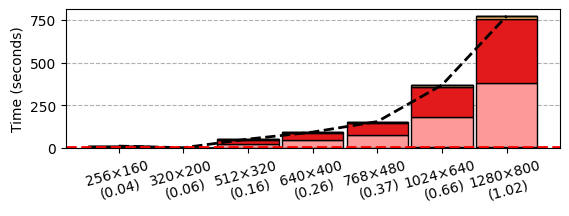

In [9]:
GROUP_BY = ["width", "height"]  # Group by resolution (width, height)

data = df_results[
    (df_results["world_size"] == WORLD_SIZE) &
    (df_results["sampling_steps"] == SAMPLING_STEPS) &
    (df_results["frames"] == FRAME_NUM)
][[
    *GROUP_BY, "txt_enc", "img_enc", "vae_enc", "sched",
    "dit_cond", "dit_uncond", "vae_dec", "output", "other_time"
]].groupby(GROUP_BY).mean().rename(columns={
    "txt_enc": "Text encode",
    "img_enc": "Image encode",
    "vae_enc": "VAE encode",
    "sched": "Scheduler",
    "dit_cond": "DiT Cond",
    "dit_uncond": "DiT Uncond",
    "vae_dec": "VAE decode",
    "output": "Output",
    "other_time": "Other",
})

fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)
colors = plt.cm.Paired(range(len(data.columns)))  # type: ignore
bottom = np.zeros(len(data))

for i, (col, color) in enumerate(zip(data.columns, colors)):
    ax.bar(
        range(len(data)),
        data[col].values,
        bottom=bottom,
        label=col,
        color=color,
        edgecolor="black",
        width=0.95
    )
    bottom += data[col].values

# Plot total time line
ax.plot(
    range(len(data)),
    data.sum(axis=1).values,
    color="black",
    linestyle='--',
    label="Total Time",
    lw=2
)

# Target time reference line
ax.axhline(y=FRAME_NUM / FPS, color="red", linestyle='--', label="Target Time", lw=2)

# Format labels as "height x width (X MP)"
res_labels = [
    f"{w}×{h}\n({w * h / 1e6:.2f})"
    for w, h in data.index
]
ax.set_xticklabels(res_labels, ha='center', rotation=15)

ax.set_xticks(range(len(data)))
#ax.set_xlabel("Width x Height (MPixels)")
ax.set_ylabel("Time (seconds)")
ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/char_resolution.{file_format}", dpi=DPI, bbox_inches='tight', pad_inches=0)
plt.show()

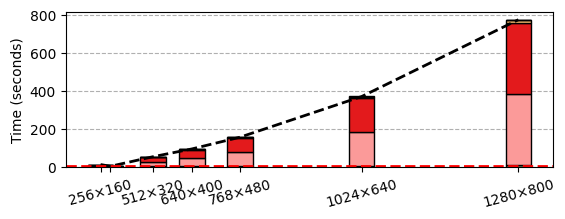

In [10]:
GROUP_BY = ["width", "height"]

# Group and average the relevant columns
data = df_results[
    (df_results["world_size"] == WORLD_SIZE) &
    (df_results["sampling_steps"] == SAMPLING_STEPS) &
    (df_results["frames"] == FRAME_NUM)
][[
    *GROUP_BY, "txt_enc", "img_enc", "vae_enc", "sched",
    "dit_cond", "dit_uncond", "vae_dec", "output", "other_time"
]].groupby(GROUP_BY).mean().rename(columns={
    "txt_enc": "Text encode",
    "img_enc": "Image encode",
    "vae_enc": "VAE encode",
    "sched": "Scheduler",
    "dit_cond": "DiT Cond",
    "dit_uncond": "DiT Uncond",
    "vae_dec": "VAE decode",
    "output": "Output",
    "other_time": "Other",
})

# Compute megapixels and sort by it
megapixels = np.array([w * h for w, h in data.index])
sorted_idx = np.argsort(megapixels)
data = data.iloc[sorted_idx]
mp_values = megapixels[sorted_idx] / 1e6  # convert to megapixels for x-axis
res_labels = [f"{w}×{h}\n({w * h / 1e6:.2f} MP)" for w, h in data.index]
res_labels = [f"{w}×{h}" for w, h in data.index]

fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)
colors = plt.cm.Paired(range(len(data.columns)))  # type: ignore
bottom = np.zeros(len(data))

for col, color in zip(data.columns, colors):
    ax.bar(
        mp_values,
        data[col].values,
        bottom=bottom,
        label=col,
        color=color,
        edgecolor="black",
        width=0.06
    )
    bottom += data[col].values

ax.plot(
    mp_values,
    data.sum(axis=1).values,
    color="black",
    linestyle='--',
    label="Total Time",
    lw=2
)

# Target latency line (based on FPS and frame count)
ax.axhline(y=FRAME_NUM / FPS, color="red", linestyle='--', label="Target Time", lw=2)

ax.set_ylabel("Time (seconds)")
ax.set_xticks(mp_values)
res_labels[1] = ""  # Avoiding overlap
ax.set_xticklabels(res_labels, ha='center', rotation=15)
ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/char_resolution.{file_format}", dpi=DPI, bbox_inches='tight', pad_inches=0)
plt.show()

## Frames
Impact to the number of frames and video duration.

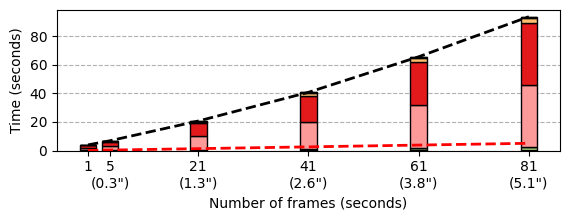

In [11]:
GROUP_BY = "frames"
data = df_results[
    (df_results["world_size"] == WORLD_SIZE) &
    (df_results["sampling_steps"] == SAMPLING_STEPS) &
    (df_results["width"] == WIDTH) &
    (df_results["height"] == HEIGHT)
][[
    GROUP_BY, "txt_enc", "img_enc", "vae_enc", "sched",
    "dit_cond", "dit_uncond", "vae_dec", "output", "other_time"
]].groupby(GROUP_BY).mean().rename(columns={
    "txt_enc": "Text encode",
    "img_enc": "Image encode",
    "vae_enc": "VAE encode",
    "sched": "Scheduler",
    "dit_cond": "DiT Cond",
    "dit_uncond": "DiT Uncond",
    "vae_dec": "VAE decode",
    "output": "Output",
    "other_time": "Other",
})

fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)
colors = plt.cm.Paired(range(len(data.columns)))
bottom = np.zeros(len(data))
for i, (col, color) in enumerate(zip(data.columns, colors)):
    ax.bar(
        data.index,
        data[col],
        bottom=bottom,
        label=col,
        color=color,
        edgecolor="black",
        width=3
    )
    bottom += data[col].values

ax.plot(
    data.index,
    data.sum(axis=1),
    color="black",
    linestyle='--',
    label="Total Time",
    lw=2)

plt.plot(
    data.index, data.index / FPS,
    color="red",
    linestyle='--',
    label="Target Time",
    lw=2)

ax.set_xticks(data.index)
res_labels = [
    f"{frames}\n({frames/FPS:.1f}\")" if frames > 1 else f"{frames}"
    for frames in data.index
]
ax.set_xticklabels(res_labels, ha='center')

ax.set_xlabel("Number of frames (seconds)")
ax.set_ylabel("Time (seconds)")
ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/char_frames.{file_format}", dpi=DPI, bbox_inches='tight', pad_inches=0)
plt.show()

## Multiple GPUs
Multiple GPUs in the same server.

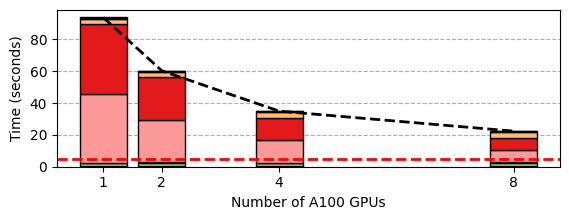

In [12]:
GROUP_BY = "world_size"
data = df_results[
    (df_results["sampling_steps"] == SAMPLING_STEPS) &
    (df_results["frames"] == FRAME_NUM) &
    (df_results["width"] == WIDTH) &
    (df_results["height"] == HEIGHT)
][[
    GROUP_BY, "txt_enc", "img_enc", "vae_enc", "sched",
    "dit_cond", "dit_uncond", "vae_dec", "output", "other_time"
]].groupby(GROUP_BY).mean().rename(columns={
    "txt_enc": "Text encode",
    "img_enc": "Image encode",
    "vae_enc": "VAE encode",
    "sched": "Scheduler",
    "dit_cond": "DiT Cond",
    "dit_uncond": "DiT Uncond",
    "vae_dec": "VAE decode",
    "output": "Output",
    "other_time": "Other",
})

fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)
colors = plt.cm.Paired(range(len(data.columns)))
bottom = np.zeros(len(data))
for i, (col, color) in enumerate(zip(data.columns, colors)):
    ax.bar(
        data.index,
        data[col],
        bottom=bottom,
        label=col,
        color=color,
        edgecolor="black"
    )
    bottom += data[col].values

ax.plot(
    data.index,
    data.sum(axis=1),
    color="black",
    linestyle='--',
    label="Total Time",
    lw=2)

ax.axhline(y=FRAME_NUM/FPS, color="red", linestyle='--', label="Target Time", lw=2)
ax.set_xticks(data.index)
ax.set_xticklabels(data.index, rotation=0)
ax.set_xlabel("Number of A100 GPUs")
ax.set_ylabel("Time (seconds)")
ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/char_num_gpus.{file_format}", dpi=DPI, bbox_inches='tight', pad_inches=0)
plt.show()

## GPU type

In [13]:
df_results = pd.read_csv(DATA_FOLDER / "wan-timing-hardware.csv")
df_results["sched"] = df_results["sched_setup"] + df_results["sched"]
df_results["other_time"] = df_results["total_time"] - (
    df_results["txt_enc"] + df_results["img_enc"] + df_results["vae_enc"] +
    df_results["dit"] + df_results["sched"] +
    df_results["vae_dec"] + df_results["output"]
)
df_results["pixels"] = df_results["width"] * df_results["height"]
df_results

,#run_id,gpu,world_size,ulysses,ring,sampling_steps,colors,frames,width,height,...,sched_setup,dit,dit_cond,dit_uncond,sched,vae_dec,output,total_time,other_time,pixels
0,0,A100,8,8,1,10,3,81,784,496,...,0.2,24.73,12.35,12.38,0.95,4.39,0.45,33.55,0.06,388864
1,0,H100,8,8,1,10,3,81,784,496,...,0.1,13.11,6.55,6.58,0.47,2.24,0.25,17.86,0.09,388864
2,0,H200,8,8,1,10,3,81,784,496,...,0.1,12.49,6.24,6.25,0.46,2.04,0.24,16.81,0.07,388864
3,0,A100,4,4,1,10,3,81,784,496,...,0.1,48.20,24.11,24.10,0.85,5.17,0.77,57.67,-0.78,388864
4,0,H100,4,4,1,10,3,81,784,496,...,0.1,25.63,12.81,12.83,0.47,2.24,0.77,30.70,-0.09,388864
5,0,H200,4,4,1,10,3,81,784,496,...,0.1,24.47,12.22,12.25,0.46,2.05,0.77,28.89,-0.52,388864
6,0,GB200,4,4,1,10,3,81,784,496,...,0.1,16.56,8.25,8.31,0.45,1.55,0.35,19.66,-0.39,388864
7,0,A100,2,2,1,10,3,81,784,496,...,0.1,92.78,46.39,46.39,0.89,5.18,0.79,102.26,-0.84,388864
8,0,GB200,2,2,1,10,3,81,784,496,...,0.1,31.00,15.50,15.49,0.45,1.56,0.35,34.18,-0.44,388864
9,0,A100,1,1,1,10,3,81,784,496,...,0.1,160.39,80.18,80.23,0.85,5.15,0.94,169.86,-0.78,388864


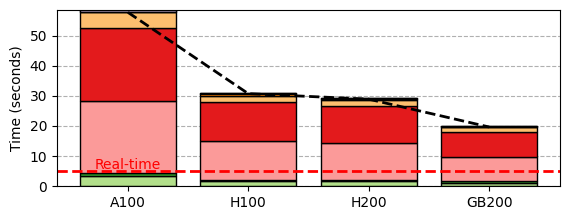

In [14]:
GROUP_BY = "gpu"
# WORLD_SIZE = 8
WORLD_SIZE = 4
# WORLD_SIZE = 1
data = df_results[
    (df_results["sampling_steps"] == SAMPLING_STEPS) &
    (df_results["frames"] == FRAME_NUM) &
    (df_results["world_size"] == WORLD_SIZE)
][[
    GROUP_BY, "txt_enc", "img_enc", "vae_enc", "sched",
    "dit_cond", "dit_uncond", "vae_dec", "output", "other_time"
]].groupby(GROUP_BY).mean().sort_values(by="dit_cond", ascending=False).rename(columns={
    "txt_enc": "Text encode",
    "img_enc": "Image encode",
    "vae_enc": "VAE encode",
    "sched": "Scheduler",
    "dit_cond": "DiT Cond",
    "dit_uncond": "DiT Uncond",
    "vae_dec": "VAE decode",
    "output": "Output",
    "other_time": "Other",
})

fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)
colors = plt.cm.Paired(range(len(data.columns)))
bottom = np.zeros(len(data))
for i, (col, color) in enumerate(zip(data.columns, colors)):
    ax.bar(
        data.index,
        data[col],
        bottom=bottom,
        label=col,
        color=color,
        edgecolor="black"
    )
    bottom += data[col].values

ax.plot(
    data.index,
    data.sum(axis=1),
    color="black",
    linestyle='--',
    label="Total Time",
    lw=2)

ax.axhline(y=FRAME_NUM/FPS, color="red", linestyle='--', label="Target Time", lw=2)
ax.text(0, FRAME_NUM/FPS + 2, "Real-time", color="red", va="center", ha="center", fontsize=10)

ax.set_xticks(data.index)
ax.set_xticklabels(data.index, rotation=0)
ax.set_ylabel("Time (seconds)")
ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/char_gputype.{file_format}", dpi=DPI, bbox_inches='tight', pad_inches=0)
plt.show()

## Multiple servers
Distributed inference across H200 servers.

In [15]:
df_results = pd.read_csv("~/realtimevideogen/paper/data/wan-timing-multiserver.csv")
df_results["sched"] = df_results["sched_setup"] + df_results["sched"]
df_results["other_time"] = df_results["total_time"] - (
    df_results["txt_enc"] + df_results["img_enc"] + df_results["vae_enc"] +
    df_results["dit"] + df_results["sched"] +
    df_results["vae_dec"] + df_results["output"]
)
df_results["pixels"] = df_results["width"] * df_results["height"]
df_results

,#run_id,gpu,world_size,ulysses,ring,sampling_steps,colors,frames,width,height,...,sched_setup,dit,dit_cond,dit_uncond,sched,vae_dec,output,total_time,other_time,pixels
0,0,H200,8,8,1,10,3,81,784,496,...,0.1,10.32,5.15,5.17,0.46,2.06,0.22,14.70,0.10,388864
1,0,H200,16,8,2,10,3,81,784,496,...,0.1,6.93,3.45,3.48,0.46,2.04,0.21,11.23,0.06,388864
2,0,H200,20,5,4,10,3,81,784,496,...,0.1,8.06,4.05,4.01,0.43,2.07,0.24,12.30,-0.02,388864
3,0,H200,24,8,3,10,3,81,784,496,...,0.1,6.74,3.39,3.35,0.47,2.04,0.22,11.08,0.08,388864
4,0,H200,32,8,4,10,3,81,784,496,...,0.1,5.57,2.79,2.75,0.46,2.06,0.21,9.85,0.01,388864
5,0,H200,40,40,1,10,3,81,784,496,...,0.1,4.25,2.13,2.12,0.46,2.05,0.24,8.57,0.05,388864
6,0,H200,80,40,2,10,3,81,784,496,...,0.1,4.13,2.09,2.06,0.46,2.04,0.25,8.41,0.00,388864


/tmp/ipykernel_2616183/2753236236.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(res_labels, ha='center')


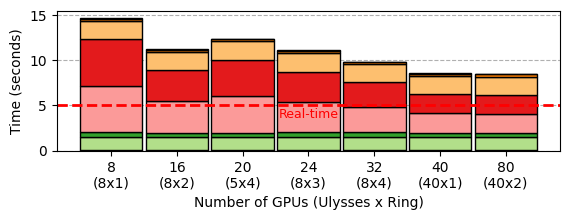

In [16]:
GROUP_BY = ["world_size", "ulysses", "ring"]
data = df_results[
    (df_results["sampling_steps"] == SAMPLING_STEPS) &
    (df_results["frames"] == FRAME_NUM)
][[
    *GROUP_BY, "txt_enc", "img_enc", "vae_enc", "sched",
    "dit_cond", "dit_uncond", "vae_dec", "output", "other_time"
]].groupby(GROUP_BY).mean().rename(columns={
    "txt_enc": "Text encode",
    "img_enc": "Image encode",
    "vae_enc": "VAE encode",
    "sched": "Scheduler",
    "dit_cond": "DiT Cond",
    "dit_uncond": "DiT Uncond",
    "vae_dec": "VAE decode",
    "output": "Output",
    "other_time": "Other",
})

fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)
colors = plt.cm.Paired(range(len(data.columns)))
bottom = np.zeros(len(data))
for i, (col, color) in enumerate(zip(data.columns, colors)):
    ax.bar(
        range(len(data)),
        data[col].values,
        bottom=bottom,
        label=col,
        color=color,
        edgecolor="black",
        width=0.95
    )
    bottom += data[col].values

# Format labels as "height x width (X MP)"
res_labels = [
    f"{world_size}\n({ulysses}x{ring})"
    for world_size, ulysses, ring in data.index
]
ax.set_xticklabels(res_labels, ha='center')

ax.set_xticks(range(len(data)))

ax.axhline(y=FRAME_NUM/FPS, color="red", linestyle='--', label="Target Time", lw=2)
ax.text(3, FRAME_NUM/FPS - 1, "Real-time", color="red", va="center", ha="center", fontsize=9)

ax.set_ylabel("Time (seconds)")
ax.set_xlabel("Number of GPUs (Ulysses x Ring)")
ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/char_multiserver.{file_format}", dpi=DPI, bbox_inches="tight", pad_inches=0)
plt.show()

# Simulator
## Latency vs Cost
Latency (TTFF) vs cost.

In [17]:
df_data_cost_latency_greedy = pd.read_csv(DATA_FOLDER / "provisioning_streamwise.csv", comment="#")
df_data_cost_latency_greedy["ttff_s*cost"] = df_data_cost_latency_greedy["ttff_s"] * df_data_cost_latency_greedy["cost"]

df_data_cost_latency_milp = pd.read_csv(DATA_FOLDER / "provisioning_streamwise_milp.csv", comment="#")
df_data_cost_latency_milp["ttff_s*cost"] = df_data_cost_latency_milp["ttff_s"] * df_data_cost_latency_milp["cost"]

df_data_cost_latency = df_data_cost_latency_greedy
df_data_cost_latency = df_data_cost_latency_milp

df_data_cost_latency = pd.concat([
    df_data_cost_latency_greedy, df_data_cost_latency_milp
]).reset_index(drop=True)

In [18]:
df_data_cost_latency.sort_values(by=["ttff_s", "cost"])
# df_data_cost_latency.sort_values(by=["ttff_s*cost"]).head(20)

,num_a100,num_h100,num_h200,num_gb200,ttff_s,tbf_s,cost,total_time,energy,ttff_s*cost
23234,0,0,0,200,10.89,0.02,182.97,306.09,4.496944e+08,1.992543e+03
23610,0,0,0,264,10.89,0.02,183.51,232.56,4.565124e+08,1.998424e+03
23235,0,0,0,256,10.89,0.04,467.43,610.89,9.388169e+08,5.090313e+03
23266,0,0,0,256,10.89,0.04,467.43,610.89,9.388169e+08,5.090313e+03
23276,0,0,0,256,10.89,0.04,467.43,610.89,1.499450e+09,5.090313e+03
...,...,...,...,...,...,...,...,...,...,...
23522,32,0,0,0,28800.00,0.18,23.05,2423.66,4.815194e+07,6.638400e+05
23523,32,0,0,0,28800.00,0.18,23.05,2423.66,4.815194e+07,6.638400e+05
23586,0,0,32,0,28800.00,0.08,42.64,1136.62,3.019555e+07,1.228032e+06
23556,0,32,0,0,28800.00,0.09,43.14,1204.18,3.006047e+07,1.242432e+06


In [19]:
df_data_cost_latency_naive = pd.read_csv(DATA_FOLDER / "provisioning_naive.csv", comment="#")
df_data_cost_latency_naive_spot = pd.read_csv(DATA_FOLDER / "provisioning_naive_spot.csv", comment="#")

In [20]:
df_data_cost_latency_a100 = df_data_cost_latency[
    (df_data_cost_latency["num_a100"] > 0) &
    (df_data_cost_latency["num_h100"] == 0) &
    (df_data_cost_latency["num_h200"] == 0) &
    (df_data_cost_latency["num_gb200"] == 0)
]
df_data_cost_latency_h100 = df_data_cost_latency[
    (df_data_cost_latency["num_a100"] == 0) &
    (df_data_cost_latency["num_h100"] > 0) &
    (df_data_cost_latency["num_h200"] == 0) &
    (df_data_cost_latency["num_gb200"] == 0)
]
df_data_cost_latency_h200 = df_data_cost_latency[
    (df_data_cost_latency["num_a100"] == 0) &
    (df_data_cost_latency["num_h100"] == 0) &
    (df_data_cost_latency["num_h200"] > 0) &
    (df_data_cost_latency["num_gb200"] == 0)
]
df_data_cost_latency_gb200 = df_data_cost_latency[
    (df_data_cost_latency["num_a100"] == 0) &
    (df_data_cost_latency["num_h100"] == 0) &
    (df_data_cost_latency["num_h200"] == 0) &
    (df_data_cost_latency["num_gb200"] > 0)
]
# Everything else
df_data_cost_latency_mixed = df_data_cost_latency[~(
    ((df_data_cost_latency["num_a100"] > 0) & 
        (df_data_cost_latency["num_h100"] == 0) & 
        (df_data_cost_latency["num_h200"] == 0) & 
        (df_data_cost_latency["num_gb200"] == 0)) |
    ((df_data_cost_latency["num_a100"] == 0) & 
        (df_data_cost_latency["num_h100"] > 0) & 
        (df_data_cost_latency["num_h200"] == 0) & 
        (df_data_cost_latency["num_gb200"] == 0)) |
    ((df_data_cost_latency["num_a100"] == 0) & 
        (df_data_cost_latency["num_h100"] == 0) & 
        (df_data_cost_latency["num_h200"] > 0) &
        (df_data_cost_latency["num_gb200"] == 0)) |
    ((df_data_cost_latency["num_a100"] == 0) & 
        (df_data_cost_latency["num_h100"] == 0) & 
        (df_data_cost_latency["num_h200"] == 0) &
        (df_data_cost_latency["num_gb200"] > 0))
)]

In [21]:
def get_datapoint(
    df: pd.DataFrame,
    num_a100: int,
    num_h100: int,
    num_h200: int,
    num_gb200: int
) -> Optional[np.ndarray]:
    filtered = df[
        (df["num_a100"] == num_a100) &
        (df["num_h100"] == num_h100) &
        (df["num_h200"] == num_h200) &
        (df["num_gb200"] == num_gb200)
    ][["ttff_s", "cost"]].sort_values(by=["ttff_s", "cost"]).to_numpy()
    if len(filtered) == 0:
        return None
    return filtered[0]

In [22]:
# Some interesting datapoints
datapoint_interest = {
    "8xA100": get_datapoint(df_data_cost_latency, 8, 0, 0, 0),
    "16xA100": get_datapoint(df_data_cost_latency, 16, 0, 0, 0),
    "8xH100": get_datapoint(df_data_cost_latency, 0, 8, 0, 0),
    # "8xH200": get_datapoint(df_data_cost_latency, 0, 0, 8, 0),
    "8xGB200": get_datapoint(df_data_cost_latency, 0, 0, 0, 8),
    "200x\nGB200": get_datapoint(df_data_cost_latency, 0, 0, 0, 200),
    "32xH200": get_datapoint(df_data_cost_latency, 0, 0, 32, 0),
    "192xH100": get_datapoint(df_data_cost_latency, 0, 192, 0, 0),
    # "112xH100": get_datapoint(df_data_cost_latency, 0, 112, 0, 0),
    # "1536xH200": get_datapoint(df_data_cost_latency, 0, 0, 256, 0),
    # "40xA100\n+160xH100": get_datapoint(df_data_cost_latency, 40, 160, 0, 0),
    # "160xA100\n+64xH200": get_datapoint(df_data_cost_latency, 160, 0, 64, 0),
    "256xA100\n+64xH200": get_datapoint(df_data_cost_latency, 256, 0, 64, 0),
    "1456xH100": get_datapoint(df_data_cost_latency, 0, 1456, 0, 0),
}

In [23]:
datapoint_naive_8xa100 = get_datapoint(df_data_cost_latency_naive, 8, 0, 0, 0)

In [24]:
datapoint_naive_spot_8xa100 = get_datapoint(df_data_cost_latency_naive_spot, 8, 0, 0, 0)

In [25]:
def get_pareto_frontier(
    points: np.ndarray | pd.DataFrame,
    max_y: Optional[int] = None,
    max_x: Optional[int] = None,
)-> np.ndarray:
    if isinstance(points, pd.DataFrame):
        points = points.to_numpy()
    return get_pareto_frontier_paper(
        points,
        max_y=max_y,
        max_x=max_x)

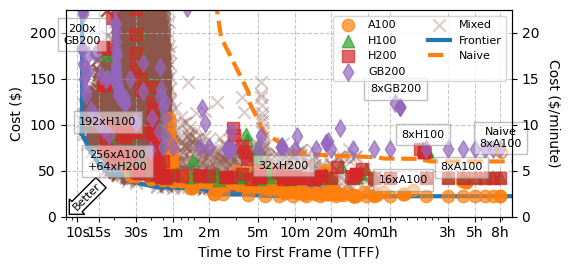

In [26]:
fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE_TALL)

MAX_COST = 225

colors = get_color_map()
for label, (df, color, marker) in {
    "A100": (df_data_cost_latency_a100, colors[1], "o"),
    "H100": (df_data_cost_latency_h100, colors[2], "^"),
    "H200": (df_data_cost_latency_h200, colors[3], "s"),
    "GB200": (df_data_cost_latency_gb200, colors[4], "d"),
    "Mixed": (df_data_cost_latency_mixed, colors[5], "x"),
}.items():
    df.plot(
        x="ttff_s",
        y="cost",
        kind="scatter",
        #xlim=(8, None),
        ylim=(0, MAX_COST),
        s=80,
        alpha=0.3 if label == "Mixed" else 0.7,
        color=color,
        label=label,
        ax=ax,
        marker=marker,
        zorder=0 if label == "Mixed" else 1
    )
plt.text(
    x=12,
    y=22,
    s="Better",
    ha="center",
    va="center",
    rotation=45,
    size=8,
    bbox=dict(boxstyle="larrow,pad=0.2", fc="white", ec="black", lw=1))

pareto_front = get_pareto_frontier(
    df_data_cost_latency[["ttff_s", "cost"]],
    max_x=10 * SECONDS_IN_HOUR,
)
plt.plot(
    pareto_front[:, 0],
    pareto_front[:, 1],
    color=colors[0],
    linewidth=3,
    #linestyle='--',
    label="Frontier",
    zorder=0
)

# pareto_front_naive = get_pareto_frontier(df_data_cost_latency_naive[["ttff_s", "cost"]])
pareto_front_naive_spot = get_pareto_frontier(
    df_data_cost_latency_naive_spot[["ttff_s", "cost"]],
    max_x=10 * SECONDS_IN_HOUR,
)
plt.plot(
    pareto_front_naive_spot[:, 0],
    pareto_front_naive_spot[:, 1],
    color=colors[1],
    linewidth=3,
    linestyle='--',
    label="Naive",
    zorder=0
)

# Labels for some configurations
for label, datapoint in datapoint_interest.items():
    if datapoint is not None:
        plt.text(
            datapoint[0],
            datapoint[1]+15,
            label,
            ha="center",
            va="center",
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'),
            size=8)

# Naive data point with 8xA100
cost_naive = datapoint_naive_8xa100[1]  # Cost in dollars
ttff_naive = datapoint_naive_8xa100[0]  # Time to first frame in seconds
cost_naive_spot = datapoint_naive_spot_8xa100[1]
ttff_naive_spot = datapoint_naive_spot_8xa100[0]
plt.plot(
    ttff_naive_spot,  # ttff_naive,
    cost_naive_spot,  # ttff_naive
    marker='o',
    markerfacecolor='none',
    lw=2,
    markeredgecolor=colors[1], 
    markersize=8)
plt.text(
    ttff_naive_spot+15,
    cost_naive_spot+15,
    "Naive\n8xA100",
    ha="center",
    va="center",
    bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'),
    size=8)

ticks, tick_labels = _get_time_ticklabels()
plt.xscale("log")
plt.xticks(ticks, tick_labels)
plt.xlim(8, 10 * SECONDS_IN_HOUR)

plt.legend(
    loc="upper right",
    ncol=2,
    fontsize=8)

plt.xlabel("Time to First Frame (TTFF)")
plt.ylabel("Cost ($)")

ax.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

ax2 = ax.twinx()
PODCAST_MINUTES = 10
ax2.set_ylim(0, MAX_COST / PODCAST_MINUTES)  # Cost 10-minute video => $/minute
ax2.set_ylabel("Cost ($/minute)", rotation=-90, labelpad=15)

plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/eval_ttff_cost.{file_format}", dpi=DPI, bbox_inches="tight", pad_inches=0)
plt.show()

### MILP vs Greedy

In [27]:
pareto_greedy = get_pareto_frontier(
    df_data_cost_latency_greedy[["ttff_s", "cost"]],
    max_x=10 * SECONDS_IN_HOUR,
)
pareto_milp = get_pareto_frontier(
    df_data_cost_latency_milp[["ttff_s", "cost"]],
    max_x=10 * SECONDS_IN_HOUR,
)
pareto_naive_spot = get_pareto_frontier(
    df_data_cost_latency_naive_spot[["ttff_s", "cost"]],
    max_x=10 * SECONDS_IN_HOUR,
)

In [28]:
def get_policy_color(label: str) -> str:
    colors = get_color_map()
    color_map = {
        "Greedy": colors[0],
        "Optimal": colors[2],
        "Naive": colors[1],
    }
    return color_map.get(label, "black")

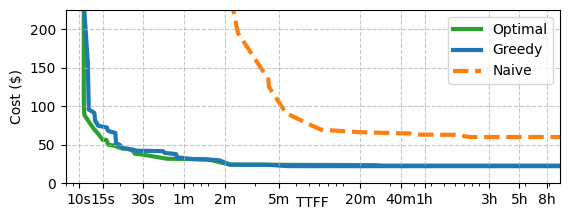

In [29]:
fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)

for pareto_name, pareto_front in {
    "Optimal": pareto_milp,
    "Greedy": pareto_greedy,
    "Naive": pareto_naive_spot,
}.items():
    plt.plot(
        pareto_front[:, 0],
        pareto_front[:, 1],
        linewidth=3,
        color=get_policy_color(pareto_name),
        linestyle="--" if pareto_name == "Naive" else "-",
        label=f"{pareto_name}",
        zorder=0
    )

plt.ylim(0, MAX_COST)

ticks, tick_labels = _get_time_ticklabels(exclude_x=[10*60])
plt.xscale("log")
plt.xticks(ticks, tick_labels)
plt.xlim(8, 10 * SECONDS_IN_HOUR)

plt.legend(loc="upper right")

plt.xlabel("TTFF", labelpad=-8)
plt.ylabel("Cost ($)")

ax.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(
        f"{OUT_FOLDER}/eval_greedy_milp.{file_format}",
        dpi=DPI, bbox_inches="tight", pad_inches=0)
plt.show()

#### Difference

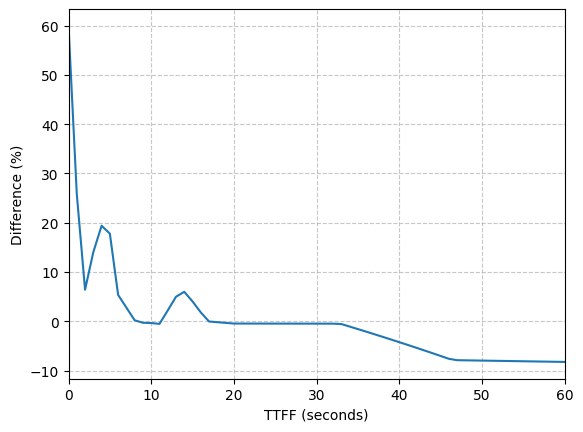

In [30]:
from utils import area_between_frontiers

pareto_diff = area_between_frontiers(pareto_milp, pareto_greedy)
plt.plot(pareto_diff)
plt.ylabel("Difference (%)")
plt.xlabel("TTFF (seconds)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 60)  # 1 minute
plt.show()

### Quality

In [31]:
df_data_cost_latency_qualities: dict[str, pd.DataFrame] = {}
for quality in [
    "high",
    "medium",
    "low",
]:
    df_data_cost_latency_qualities[quality] = pd.read_csv(
        DATA_FOLDER / f"provisioning_streamwise_{quality}.csv",
        comment="#")   

df_data_cost_latency_qualities["low"].sort_values(by="ttff_s")

,num_a100,num_h100,num_h200,num_gb200,ttff_s,tbf_s,cost,total_time,energy
1692,0,0,0,171,1.34,0.00,10.24,19.46,0.0
1691,0,0,0,171,1.34,0.00,10.24,19.46,0.0
1656,0,0,0,171,1.34,0.00,10.24,19.46,0.0
1645,0,0,0,171,1.34,0.00,10.24,19.46,0.0
1701,0,0,0,171,1.34,0.00,10.24,19.46,0.0
...,...,...,...,...,...,...,...,...,...
745,0,0,8,0,7.20,0.04,4.60,490.98,0.0
9,24,0,0,0,7.51,0.03,2.53,354.47,0.0
0,0,8,0,0,7.61,0.04,4.66,520.60,0.0
4,16,0,0,0,10.40,0.03,2.16,455.04,0.0


In [32]:
df_data_cost_latency_quality_adaptive = pd.read_csv(DATA_FOLDER / "provisioning_streamwise_adaptive.csv", comment="#")
df_data_cost_latency_quality_adaptive.sort_values(by="ttff_s")

,num_a100,num_h100,num_h200,num_gb200,ttff_s,tbf_s,cost,total_time,energy
1692,383,0,241,0,1.34,0.00,81.73,19.46,0.0
1691,254,0,0,256,1.34,0.00,159.76,19.46,0.0
1656,24,0,0,171,1.34,0.00,171.19,19.46,0.0
1645,24,0,0,171,1.34,0.00,72.48,19.46,0.0
1701,40,0,0,171,1.34,0.00,83.51,19.46,0.0
...,...,...,...,...,...,...,...,...,...
745,0,0,8,0,7.20,0.04,70.16,490.98,0.0
9,0,40,0,0,7.51,0.03,49.43,354.47,0.0
0,0,8,0,0,7.61,0.04,71.01,520.60,0.0
4,16,40,0,0,10.40,0.03,39.72,455.04,0.0


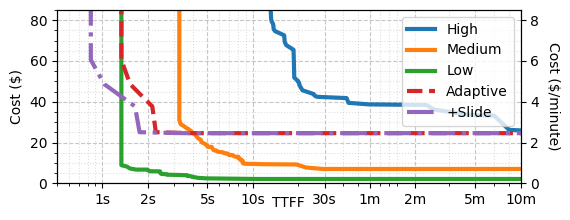

In [33]:
fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)
for quality, df in df_data_cost_latency_qualities.items():
    pareto_front = get_pareto_frontier(
        df[["ttff_s", "cost"]],
        max_x=10 * SECONDS_IN_HOUR,
        max_y=100,
    )
    plt.plot(pareto_front[:, 0],
         pareto_front[:, 1],
         linewidth=3,
         label=quality.capitalize())

pareto_front = get_pareto_frontier(
    df_data_cost_latency_quality_adaptive[["ttff_s", "cost"]],
    max_x=10 * SECONDS_IN_HOUR,
)
plt.plot(pareto_front[:, 0],
         pareto_front[:, 1],
         linewidth=3,
         linestyle='--',
         label="Adaptive")
pareto_front = get_pareto_frontier(
    df_data_cost_latency_quality_adaptive[["ttff_s", "cost"]],
    max_x=10 * SECONDS_IN_HOUR,
)
SLIDE_SECONDS = 0.5
plt.plot(pareto_front[:, 0]-SLIDE_SECONDS,
         pareto_front[:, 1],
         linewidth=3,
         linestyle='-.',
         label="+Slide")

ticks, tick_labels = _get_time_ticklabels(exclude_x=[15])
plt.xscale("log")
plt.xticks(ticks, tick_labels)

plt.legend(loc="upper right", fontsize=10)

ax.set_xlabel("TTFF", labelpad=-8)
ax.set_ylabel("Cost ($)")
max_y = 85
ax.set_ylim(0, max_y)
ax.set_xlim(0.5, 10 * 60)  # 10 minutes to zoom in

ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))

ax.grid(True, which='major', linestyle='--', alpha=0.7)
ax.grid(True, which='minor', linestyle=':', alpha=0.4)

ax2 = ax.twinx()
ax2.set_ylim(0, max_y / 10)  # Scale by 1/10 cost/10 minutes
ax2.set_ylabel("Cost ($/minute)", rotation=-90, labelpad=15)

plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(
        f"{OUT_FOLDER}/eval_ttff_cost_quality_frontier.{file_format}",
        dpi=DPI, bbox_inches="tight", pad_inches=0)
plt.show()

## Multiple requests

In [34]:
df_qpm = pd.read_csv(f"{DATA_FOLDER}/provisioning_qpm.csv")
df_qpm = df_qpm.drop(columns=["Total"])

In [35]:
df_qpm

,QPM,Kokoro,Gemma,Flux,FramePack,FramePack VAE,Fantasy Talking,Real-ESRGAN
0,0.5,1.07,8.56,17.12,100.75,14.73,386.88,158.49
1,1.0,1.07,8.56,17.12,100.75,14.73,826.15,158.49
2,2.0,1.07,8.56,17.12,100.75,25.44,1652.30,180.60
3,5.0,3.21,8.56,17.12,225.68,62.94,4130.75,445.98
4,10.0,5.35,13.91,17.12,447.33,125.87,8261.50,888.28
5,20.0,9.63,27.82,17.12,890.63,250.41,16523.00,1776.56
6,30.0,13.91,41.73,17.12,1337.96,374.95,24784.50,2661.16
7,50.0,23.54,69.55,17.12,2224.56,625.36,41307.50,4434.03
8,100.0,46.01,139.10,27.82,4449.12,1250.71,82615.00,8868.07


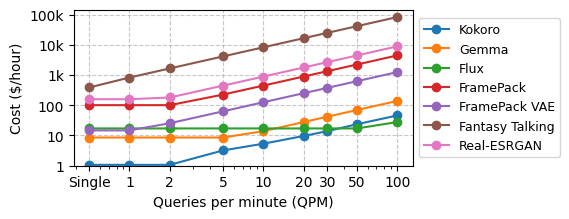

In [36]:
fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)
df_qpm.set_index("QPM").plot(
    ylabel="Cost ($/hour)",
    xlabel="Queries per minute (QPM)",
    marker='o',
    # stacked=True,
    ylim=[1, None],
    logy=True,
    logx=True,
    ax=ax,
)
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.set_xticks(df_qpm["QPM"])

# Show the y axis to be $1, $10, $100, $1k
#ax.set_yticks([1, 10, 100, 1000, 10000, 100000])
#ax.set_yticklabels(["1", "10", "100", "1k", "10k", "100k"])

#ax.set_yticks([1, 10, 100, 1000, 10000])
#ax.set_yticklabels(["1", "10", "100", "1k", "10k"])

#ax.set_yticks([0, 20000, 40000, 60000, 80000])
#ax.set_yticklabels(["0", "20k", "40k", "60k", "80k"])

ax.set_yticks([1, 10, 100, 1000, 10*1000, 100*1000])
ax.set_yticklabels(["1", "10", "100", "1k", "10k", "100k"])

ax.set_xticks([0.5, 1, 2, 5, 10, 20, 30, 50, 100])
ax.set_xticklabels(["Single", "1", "2", "5", "10", "20", "30", "50", "100"])

#plt.legend(ncols=2, loc='lower right', fontsize=9)
plt.legend(ncols=1, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/eval_cost_qpm.{file_format}", dpi=DPI, bbox_inches="tight", pad_inches=0)
plt.show()

## Ablation
### Naive + Feature

In [37]:
df_ablation_baseline   = pd.read_csv(DATA_FOLDER / "provisioning_naive.csv", comment="#")
df_ablation_spot       = pd.read_csv(DATA_FOLDER / "provisioning_naive_spot.csv", comment="#")
df_ablation_disagg     = pd.read_csv(DATA_FOLDER / "provisioning_naive_disag.csv", comment="#")
df_ablation_qual       = pd.read_csv(DATA_FOLDER / "provisioning_naive_upscaler.csv", comment="#")
df_ablation_scheduler  = pd.read_csv(DATA_FOLDER / "provisioning_naive_time_cost_allocator.csv", comment="#")
df_ablation_hardware   = pd.read_csv(DATA_FOLDER / "provisioning_naive_hardware.csv", comment="#")
df_ablation_streamwise = pd.read_csv(DATA_FOLDER / "provisioning_streamwise.csv", comment="#")

In [38]:
df_ablation_baseline_a100 = df_ablation_hardware[
    (df_ablation_hardware["num_h100"] == 0) &
    (df_ablation_hardware["num_h200"] == 0) &
    (df_ablation_hardware["num_a100"] > 0) &
    (df_ablation_hardware["num_gb200"] == 0)
]
df_ablation_baseline_h100 = df_ablation_hardware[
    (df_ablation_hardware["num_h100"] > 0) &
    (df_ablation_hardware["num_h200"] == 0) &
    (df_ablation_hardware["num_a100"] == 0) &
    (df_ablation_hardware["num_gb200"] == 0)
]
df_ablation_baseline_h200 = df_ablation_hardware[
    (df_ablation_hardware["num_h100"] == 0) &
    (df_ablation_hardware["num_h200"] > 0) &
    (df_ablation_hardware["num_a100"] == 0) &
    (df_ablation_hardware["num_gb200"] == 0)
]
df_ablation_baseline_gb200 = df_ablation_hardware[
    (df_ablation_hardware["num_h100"] == 0) &
    (df_ablation_hardware["num_h200"] == 0) &
    (df_ablation_hardware["num_a100"] == 0) &
    (df_ablation_hardware["num_gb200"] > 0)
]

In [39]:
pareto_front_a100     = get_pareto_frontier(df_ablation_baseline_a100[["ttff_s", "cost"]])
pareto_front_h100     = get_pareto_frontier(df_ablation_baseline_h100[["ttff_s", "cost"]], max_y=6000)
pareto_front_h200     = get_pareto_frontier(df_ablation_baseline_h200[["ttff_s", "cost"]])
pareto_front_baseline = get_pareto_frontier(df_ablation_baseline[["ttff_s", "cost"]])

In [40]:
# Set the baseline to be A100 only
df_ablation_baseline = df_ablation_baseline[
    (df_ablation_baseline["num_h100"] == 0) &
    (df_ablation_baseline["num_h200"] == 0) &
    (df_ablation_baseline["num_a100"] > 0) &
    (df_ablation_baseline["num_gb200"] == 0)
]
df_ablation_spot = df_ablation_spot[
    (df_ablation_spot["num_h100"] == 0) &
    (df_ablation_spot["num_h200"] == 0) &
    (df_ablation_spot["num_a100"] > 0) &
    (df_ablation_spot["num_gb200"] == 0)
]
df_ablation_disagg = df_ablation_disagg[
    (df_ablation_disagg["num_h100"] == 0) &
    (df_ablation_disagg["num_h200"] == 0) &
    (df_ablation_disagg["num_a100"] > 0) &
    (df_ablation_disagg["num_gb200"] == 0)
]
df_ablation_qual = df_ablation_qual[
    (df_ablation_qual["num_h100"] == 0) &
    (df_ablation_qual["num_h200"] == 0) &
    (df_ablation_qual["num_a100"] > 0) &
    (df_ablation_qual["num_gb200"] == 0)
]
df_ablation_scheduler = df_ablation_scheduler[
    (df_ablation_scheduler["num_h100"] == 0) &
    (df_ablation_scheduler["num_h200"] == 0) &
    (df_ablation_scheduler["num_a100"] > 0) &
    (df_ablation_scheduler["num_gb200"] == 0)
]

In [41]:
pareto_front_baseline   = get_pareto_frontier(
    df_ablation_baseline[["ttff_s", "cost"]],
    max_y=5000, max_x=10*SECONDS_IN_HOUR)
pareto_front_hardware   = get_pareto_frontier(
    df_ablation_hardware[["ttff_s", "cost"]],
    max_y=5000, max_x=10*SECONDS_IN_HOUR)
pareto_front_spot       = get_pareto_frontier(
    df_ablation_spot[["ttff_s", "cost"]],
    max_y=5000, max_x=10*SECONDS_IN_HOUR)
pareto_front_disagg     = get_pareto_frontier(
    df_ablation_disagg[["ttff_s", "cost"]],
    max_y=5000, max_x=10*SECONDS_IN_HOUR)
pareto_front_qual       = get_pareto_frontier(
    df_ablation_qual[["ttff_s", "cost"]],
    max_y=5000, max_x=10*SECONDS_IN_HOUR)
pareto_front_scheduler  = get_pareto_frontier(
    df_ablation_scheduler[["ttff_s", "cost"]],
    max_y=5000, max_x=10*SECONDS_IN_HOUR)
pareto_front_streamwise = get_pareto_frontier(
    df_ablation_streamwise[["ttff_s", "cost"]],
    max_y=5000, max_x=10*SECONDS_IN_HOUR)

# Adaptive quality
pareto_front_adaptive   = get_pareto_frontier(
    df_data_cost_latency_quality_adaptive[["ttff_s", "cost"]], max_y=5000, max_x=10*SECONDS_IN_HOUR)

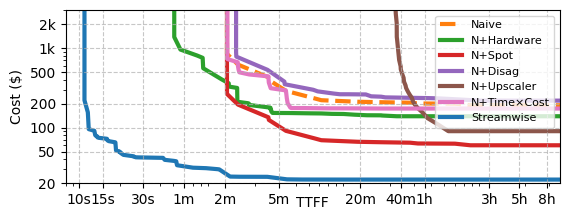

In [42]:
colors = get_color_map()

fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)

for label, (pareto_front, ls, lc) in {
    "Naive": (pareto_front_baseline, '--', colors[1]),
    "N+Hardware": (pareto_front_hardware, '-', colors[2]),
    "N+Spot": (pareto_front_spot, '-', colors[3]),
    "N+Disag": (pareto_front_disagg, '-', colors[4]),
    "N+Upscaler": (pareto_front_qual, '-', colors[5]),
    "N+Time×Cost": (pareto_front_scheduler, '-', colors[6]),
    "Streamwise": (pareto_front_streamwise, '-', colors[0]),
    # "Adaptive": (pareto_front_adaptive, '-', colors[7]),
}.items():
    plt.plot(
        pareto_front[:, 0],
        pareto_front[:, 1],
        color=lc,
        linewidth=3,
        linestyle=ls,
        label=label,
        zorder=0)

# X-axis
ticks, tick_labels = _get_time_ticklabels(exclude_x=[10*60])
plt.xscale("log")
plt.xticks(ticks, tick_labels)
plt.xlim(8, 10 * SECONDS_IN_HOUR)
# plt.xlabel("Time to First Frame (TTFF)")
ax.set_xlabel("TTFF", labelpad=-8)

# Y-axis
plt.yscale("log")
plt.yticks(
    [20, 50, 100, 200, 500, 1000, 2000],
    ["20", "50", "100", "200", "500", "1k", "2k"])
plt.ylim(20, 3000)
plt.ylabel("Cost ($)")

plt.legend(loc="upper right", fontsize=8)

ax.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# ax2 = ax.twinx()
# ax2.set_ylim(0, MAX_COST / 10)  # Cost 10-minute video => $/minute
# ax2.set_ylabel("Cost ($/minute)", rotation=-90, labelpad=15)

plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/ablation.{file_format}", dpi=DPI, bbox_inches="tight", pad_inches=0)

plt.tight_layout(pad=0)
plt.show()

### StreamWise - Feature

In [43]:
df_ablation_streamwise             = pd.read_csv(DATA_FOLDER / "provisioning_streamwise.csv", comment="#")
df_ablation_streamwise_no_spot     = pd.read_csv(DATA_FOLDER / "provisioning_streamwise_no_spot.csv", comment="#")
df_ablation_streamwise_no_disagg   = pd.read_csv(DATA_FOLDER / "provisioning_streamwise_no_disag.csv", comment="#")
df_ablation_streamwise_disagg      = pd.read_csv(DATA_FOLDER / "provisioning_streamwise_disag.csv", comment="#")
df_ablation_streamwise_no_upscaler = pd.read_csv(DATA_FOLDER / "provisioning_streamwise_no_upscaler.csv", comment="#")
df_ablation_streamwise_naive       = pd.read_csv(DATA_FOLDER / "provisioning_streamwise_naive.csv", comment="#")
df_ablation_streamwise_a100        = pd.read_csv(DATA_FOLDER / "provisioning_streamwise_A100.csv", comment="#")

In [44]:
pareto_front_streamwise             = get_pareto_frontier(df_ablation_streamwise[["ttff_s", "cost"]], max_y=5000, max_x=2 * SECONDS_IN_HOUR)
pareto_front_streamwise_no_spot     = get_pareto_frontier(df_ablation_streamwise_no_spot[["ttff_s", "cost"]], max_y=5000, max_x=2 * SECONDS_IN_HOUR)
pareto_front_streamwise_no_disagg   = get_pareto_frontier(df_ablation_streamwise_no_disagg[["ttff_s", "cost"]], max_y=5000, max_x=2 * SECONDS_IN_HOUR)
pareto_front_streamwise_disagg      = get_pareto_frontier(df_ablation_streamwise_disagg[["ttff_s", "cost"]], max_y=5000, max_x=2 * SECONDS_IN_HOUR)
pareto_front_streamwise_no_upscaler = get_pareto_frontier(df_ablation_streamwise_no_upscaler[["ttff_s", "cost"]], max_y=5000, max_x=2 * SECONDS_IN_HOUR)
pareto_front_streamwise_naive       = get_pareto_frontier(df_ablation_streamwise_naive[["ttff_s", "cost"]], max_y=5000, max_x=2 * SECONDS_IN_HOUR)
pareto_front_streamwise_a100        = get_pareto_frontier(df_ablation_streamwise_a100[["ttff_s", "cost"]], max_y=5000, max_x=2 * SECONDS_IN_HOUR)

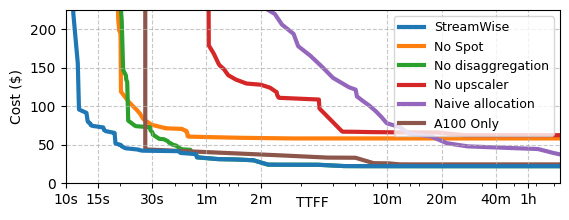

In [45]:
fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)

for label, pareto_front in [
    ("StreamWise", pareto_front_streamwise),
    ("No Spot", pareto_front_streamwise_no_spot),
    ("No disaggregation", pareto_front_streamwise_no_disagg),
    ("No upscaler", pareto_front_streamwise_no_upscaler),
    ("Naive allocation", pareto_front_streamwise_naive),
    ("A100 Only", pareto_front_streamwise_a100),
]:
    plt.plot(
        pareto_front[:, 0],
        pareto_front[:, 1],
        linewidth=3,
        label=label,
        zorder=1 if label == "StreamWise" else 0)

# X-axis
ticks, tick_labels = _get_time_ticklabels(exclude_x=[5 * 60])
plt.xscale("log")
plt.xticks(ticks, tick_labels)
plt.xlim(10, 1.5 * SECONDS_IN_HOUR)
ax.set_xlabel("TTFF", labelpad=-8)

# Y-axis
plt.ylim(0, 300)
plt.ylim(0, 225)
plt.ylabel("Cost ($)")

plt.legend(loc="upper right", fontsize=9)

ax.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/ablation_minus.{file_format}", dpi=DPI, bbox_inches="tight", pad_inches=0)

plt.tight_layout(pad=0)
plt.show()

## Disaggregation

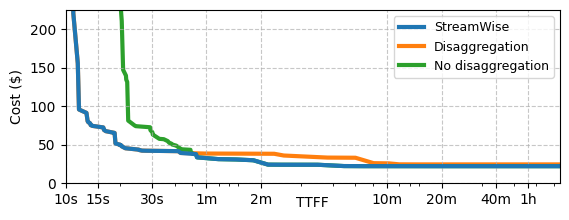

In [46]:
fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)

for label, pareto_front in [
    ("StreamWise", pareto_front_streamwise),
    ("Disaggregation", pareto_front_streamwise_disagg),
    ("No disaggregation", pareto_front_streamwise_no_disagg),
]:
    plt.plot(
        pareto_front[:, 0],
        pareto_front[:, 1],
        linewidth=3,
        label=label,
        zorder=1 if label == "StreamWise" else 0)

# X-axis
ticks, tick_labels = _get_time_ticklabels(exclude_x=[5 * 60])
plt.xscale("log")
plt.xticks(ticks, tick_labels)
plt.xlim(10, 1.5 * SECONDS_IN_HOUR)
ax.set_xlabel("TTFF", labelpad=-8)

# Y-axis
plt.ylim(0, 300)
plt.ylim(0, 225)
plt.ylabel("Cost ($)")

plt.legend(loc="upper right", fontsize=9)

ax.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/ablation_disaggregation.{file_format}", dpi=DPI, bbox_inches="tight", pad_inches=0)

plt.tight_layout(pad=0)
plt.show()

## Workflows

In [47]:
from workflows import WORKFLOW_DURATIONS

df_workflows = {}
for workflow_name in WORKFLOW_DURATIONS.keys():
    df_workflows[workflow_name] = {}
    try:
        filename = DATA_FOLDER / f"workflows/provisioning_naive_{workflow_name}.csv"
        df_workflow = pd.read_csv(filename, comment="#")
        df_workflow["cost_per_minute"] = df_workflow["cost"] / (WORKFLOW_DURATIONS[workflow_name] / 60)
        df_workflows[workflow_name]["naive"] = df_workflow
    except FileNotFoundError:
        print(f"File not found for naive workflow {workflow_name}, skipping.")

    try:
        filename = DATA_FOLDER / f"workflows/provisioning_streamwise_{workflow_name}.csv"
        df_workflow = pd.read_csv(filename, comment="#")
        df_workflow["cost_per_minute"] = df_workflow["cost"] / (WORKFLOW_DURATIONS[workflow_name] / 60)
        df_workflows[workflow_name]["streamwise"] = df_workflow
    except FileNotFoundError:
        print(f"File not found for streamwise workflow {workflow_name}, skipping.")

In [48]:
# Pareto frontiers for each workflow and approach
pareto_front_workflows = {}
for workflow_name in WORKFLOW_DURATIONS.keys():
    pareto_front_workflows[workflow_name] = {}
    for approach in ["naive", "streamwise"]:
        if approach not in df_workflows[workflow_name]:
            print(f"Data not found for workflow {workflow_name} and approach {approach}, skipping.")
            continue
        pareto_front_workflows[workflow_name][approach] = get_pareto_frontier(
            df_workflows[workflow_name][approach][["ttff_s", "cost_per_minute"]],
            max_y=5000,
            max_x=10 * SECONDS_IN_HOUR)

In [49]:
def get_workflow_color(workflow: str) -> str:
    colors = get_color_map()
    color_map = {
        "podcast": colors[0],
        "chat": colors[1],
        "dubbing": colors[2],
        "editing": colors[3],
        "lecture": colors[4],
        "movie": colors[5],
        "short": colors[6],
        "slide": colors[7],
        "story": colors[8],
    }
    return color_map.get(workflow, "black")

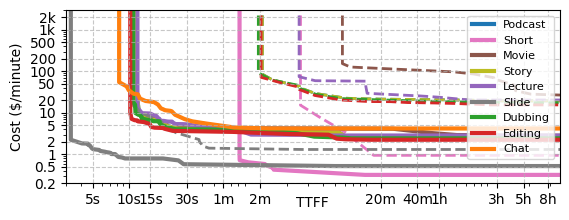

In [50]:
fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)

for workflow in WORKFLOW_DURATIONS.keys():
    for approach in ["naive", "streamwise"]:
        if approach not in pareto_front_workflows[workflow]:
            continue
        pareto_front = pareto_front_workflows[workflow][approach]
        plt.plot(
            pareto_front[:, 0],
            pareto_front[:, 1],
            color=get_workflow_color(workflow),
            linewidth=3 if approach == 'streamwise' else 2,
            ls='--' if approach == 'naive' else '-',
            label=f"{workflow.capitalize()}" if approach == 'streamwise' else "",
            zorder=0
        )

# X-axis
ticks, tick_labels = _get_time_ticklabels(exclude_x=[5*60, 10*60])
plt.xscale("log")
plt.xticks(ticks, tick_labels)
plt.xlim(3, 10 * SECONDS_IN_HOUR)
# plt.xlabel("Time to First Frame (TTFF)")
ax.set_xlabel("TTFF", labelpad=-8)

# Y-axis
plt.yscale("log")
plt.yticks(
    [0.2, 0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000],
    ["0.2", "0.5", "1", "2", "5", "10", "20", "50", "100", "200", "500", "1k", "2k"])
plt.ylim(0.2, 3 * 1000)
plt.ylabel("Cost ($/minute)")

plt.legend(loc="upper right", fontsize=8)  # 9
# plt.legend().set_visible(False)

ax.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/eval_workflows.{file_format}", dpi=DPI, bbox_inches="tight", pad_inches=0)
plt.show()

## Energy

In [51]:
df_energy = pd.read_csv(DATA_FOLDER / "provisioning_streamwise.csv", comment="#")
df_energy["total_energy_Wh"] = df_energy["energy"] / SECONDS_IN_HOUR
df_energy["total_energy_kWh"] = df_energy["total_energy_Wh"] / 1000.0

df_energy_baseline = pd.read_csv(DATA_FOLDER / "provisioning_naive.csv", comment="#")
df_energy_baseline["total_energy_Wh"] = df_energy_baseline["energy"] / SECONDS_IN_HOUR
df_energy_baseline["total_energy_kWh"] = df_energy_baseline["total_energy_Wh"] / 1000.0

In [52]:
df_energy_a100 = df_energy[
    (df_energy["num_a100"] > 0) &
    (df_energy["num_h100"] == 0) &
    (df_energy["num_h200"] == 0) &
    (df_energy["num_gb200"] == 0)
]
df_energy_h100 = df_energy[
    (df_energy["num_a100"] == 0) &
    (df_energy["num_h100"] > 0) &
    (df_energy["num_h200"] == 0) &
    (df_energy["num_gb200"] == 0)
]
df_energy_h200 = df_energy[
    (df_energy["num_a100"] == 0) &
    (df_energy["num_h100"] == 0) &
    (df_energy["num_h200"] > 0) &
    (df_energy["num_gb200"] == 0)
]
df_energy_gb200 = df_energy[
    (df_energy["num_a100"] == 0) &
    (df_energy["num_h100"] == 0) &
    (df_energy["num_h200"] == 0) &
    (df_energy["num_gb200"] > 0)
]
df_energy_mixed = df_energy[
    ~(
        ((df_energy["num_a100"] > 0) & 
            (df_energy["num_h100"] == 0) & 
            (df_energy["num_h200"] == 0) &
            (df_energy["num_gb200"] == 0)) |
        ((df_energy["num_a100"] == 0) & 
            (df_energy["num_h100"] > 0) & 
            (df_energy["num_h200"] == 0) &
            (df_energy["num_gb200"] == 0)) |
        ((df_energy["num_a100"] == 0) & 
            (df_energy["num_h100"] == 0) & 
            (df_energy["num_h200"] > 0) &
            (df_energy["num_gb200"] == 0)) |
        ((df_energy["num_a100"] == 0) & 
            (df_energy["num_h100"] == 0) & 
            (df_energy["num_h200"] == 0) &
            (df_energy["num_gb200"] > 0))
    )
]

pareto_energy = get_pareto_frontier(
    df_energy[["ttff_s", "total_energy_kWh"]],
    max_y=5000,
    max_x=10 * SECONDS_IN_HOUR,
)
pareto_energy_baseline = get_pareto_frontier(
    df_energy_baseline[["ttff_s", "total_energy_kWh"]],
    max_y=5000,
    max_x=10 * SECONDS_IN_HOUR,
)

[]

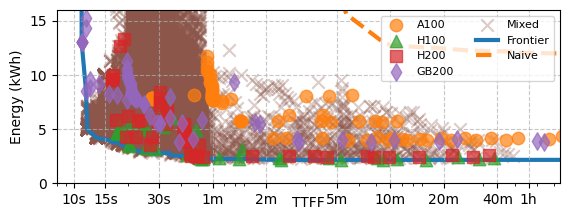

In [53]:
fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)
colors = get_color_map()

# Individual data points
for label, (df, color, marker) in {
    "A100": (df_energy_a100, colors[1], "o"),
    "H100": (df_energy_h100, colors[2], "^"),
    "H200": (df_energy_h200, colors[3], "s"),
    "GB200": (df_energy_gb200, colors[4], "d"),
    "Mixed": (df_energy_mixed, colors[5], "x"),
}.items():
    df.plot(
        x="ttff_s",
        y="total_energy_kWh",
        kind="scatter",
        # xlim=(8, None),
        # ylim=(0, MAX_COST),
        s=80,
        alpha=0.3 if label == "Mixed" else 0.7,
        color=color,
        label=label,
        ax=ax,
        marker=marker,
        zorder=0 if label == "Mixed" else 1
    )

plt.plot(
    pareto_energy[:, 0],
    pareto_energy[:, 1],
    linewidth=3,
    color=colors[0],
    label="Frontier",
    zorder=0,
)
plt.plot(
    pareto_energy_baseline[:, 0],
    pareto_energy_baseline[:, 1],
    linewidth=3,
    color=colors[1],
    linestyle='--',
    label="Naive",
)

# X-axis: TTFF
ticks, tick_labels = _get_time_ticklabels()
plt.xscale("log")
plt.xticks(ticks, tick_labels)
plt.xlim(8, 1.5 * SECONDS_IN_HOUR)
# plt.xlabel("Time to First Frame (TTFF)")
ax.set_xlabel("TTFF", labelpad=-8)

# Y-axis: cost
plt.ylim(0, 16)
plt.ylabel("Energy (kWh)")

plt.legend(
    loc="upper right",
    ncol=2,
    fontsize=8)

ax.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout(pad=0)

for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/energy.{file_format}", dpi=DPI, bbox_inches="tight", pad_inches=0)

plt.plot()

## LLM
Common LLM policies.

In [54]:
df_data_streamwise = pd.read_csv(DATA_FOLDER / "provisioning_streamwise.csv", comment="#")

df_data_naive = pd.read_csv(DATA_FOLDER / "provisioning_naive.csv", comment="#")
df_data_hexgen = pd.read_csv(DATA_FOLDER / "llm/provisioning_hexgen.csv", comment="#")
df_data_helix = pd.read_csv(DATA_FOLDER / "llm/provisioning_helix.csv", comment="#")
df_data_ddit = pd.read_csv(DATA_FOLDER / "llm/provisioning_ddit.csv", comment="#")

df_data_naive_spot = pd.read_csv(DATA_FOLDER / "provisioning_naive_spot.csv", comment="#")
df_data_hexgen_spot = pd.read_csv(DATA_FOLDER / "llm/provisioning_hexgen_spot.csv", comment="#")
df_data_helix_spot = pd.read_csv(DATA_FOLDER / "llm/provisioning_helix_spot.csv", comment="#")
df_data_ddit_spot = pd.read_csv(DATA_FOLDER / "llm/provisioning_ddit_spot.csv", comment="#")

In [55]:
pareto_front_streamwise = get_pareto_frontier(
    df_data_streamwise[["ttff_s", "cost"]],
    max_y=5000, max_x=10 * SECONDS_IN_HOUR)
pareto_front_naive = get_pareto_frontier(
    df_data_naive[["ttff_s", "cost"]],
    max_y=5000, max_x=10 * SECONDS_IN_HOUR)
pareto_front_hexgen = get_pareto_frontier(
    df_data_hexgen[["ttff_s", "cost"]],
    max_y=5000, max_x=10 * SECONDS_IN_HOUR)
pareto_front_helix = get_pareto_frontier(
    df_data_helix[["ttff_s", "cost"]],
    max_y=5000, max_x=10 * SECONDS_IN_HOUR)
pareto_front_ddit = get_pareto_frontier(
    df_data_ddit[["ttff_s", "cost"]],
    max_y=5000, max_x=10 * SECONDS_IN_HOUR)

pareto_front_naive_spot = get_pareto_frontier(
    df_data_naive_spot[["ttff_s", "cost"]],
    max_y=5000, max_x=10 * SECONDS_IN_HOUR)
pareto_front_hexgen_spot = get_pareto_frontier(
    df_data_hexgen_spot[["ttff_s", "cost"]],
    max_y=5000, max_x=10 * SECONDS_IN_HOUR)
pareto_front_helix_spot = get_pareto_frontier(
    df_data_helix_spot[["ttff_s", "cost"]],
    max_y=5000, max_x=10 * SECONDS_IN_HOUR)
pareto_front_ddit_spot = get_pareto_frontier(
    df_data_ddit_spot[["ttff_s", "cost"]],
    max_y=5000, max_x=10 * SECONDS_IN_HOUR)

In [56]:
def get_llm_color(label: str) -> str:
    colors = get_color_map()
    color_map = {
        "StreamWise": colors[0],
        "Naive": colors[1],
        "HexGen": colors[2],
        "Helix": colors[3],
        "DDiT": colors[4],
    }
    clean_label = label.replace(" (Spot)", "")
    return color_map.get(clean_label, "black")

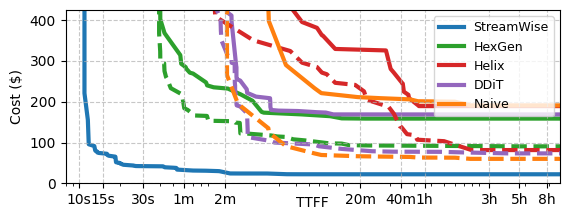

In [57]:
fig, ax = plt.subplots(figsize=PAPER_FIG_SIZE)

for label, pareto_front in {
    "StreamWise": pareto_front_streamwise,
    "HexGen": pareto_front_hexgen,
    "Helix": pareto_front_helix,
    "DDiT": pareto_front_ddit,
    "HexGen (Spot)": pareto_front_hexgen_spot,
    "Helix (Spot)": pareto_front_helix_spot,
    "DDiT (Spot)": pareto_front_ddit_spot,
    "Naive": pareto_front_naive,
    "Naive (Spot)": pareto_front_naive_spot,
}.items():
    plt.plot(
        pareto_front[:, 0],
        pareto_front[:, 1],
        color=get_llm_color(label),
        linewidth=3,
        ls='--' if "Spot" in label else '-',
        label=label if "Spot" not in label else "",
        zorder=0
    )

# X-axis
ticks, tick_labels = _get_time_ticklabels(exclude_x=[5*60, 10*60])
plt.xscale("log")
plt.xticks(ticks, tick_labels)
plt.xlim(8, 10 * SECONDS_IN_HOUR)
# plt.xlabel("Time to First Frame (TTFF)")
ax.set_xlabel("TTFF", labelpad=-8)

# Y-axis
ax.set_ylabel("Cost ($)")
max_y = 425
ax.set_ylim(0, max_y)

plt.legend(loc="upper right", fontsize=9)
# plt.legend().set_visible(False)

ax.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout(pad=0)
for file_format in FILE_FORMATS:
    plt.savefig(f"{OUT_FOLDER}/eval_llm.{file_format}", dpi=DPI, bbox_inches="tight", pad_inches=0)
plt.show()